In this notebook, we investigate the performance of our algorithm in a 100-d dimeensional space.

We have already confirmed that the algorithm performs well in low dimensions (2d Rosenbrock function) in other experiments.

Here, we seek to see how our algorithm performs in higheer dimensions.

# 100-d Rosenbrock: $\sum_{i=1}^{99} \left[ 100(x_{i+1} - x_i^2)^2 + (1 - x_i)^2 \right]$


In [ ]:
import numpy as np

def rosenbrock_100d(x):
    """Calculate the Rosenbrock function for a 100-dimensional vector x."""
    return sum(100*(x[i+1] - x[i]**2)**2 + (1 - x[i])**2 for i in range(99))

# Initial point x0, often chosen as a starting point for optimization
x0 = np.ones(100) * -1.5  # A common choice, not the minimum but typical starting point

# Example usage
value_at_x0 = rosenbrock_100d(x0)
print("Value at x0:", value_at_x0)


Value at x0: 139837.5


In [ ]:
import numpy as np
from autograd import grad
from autograd import hessian
import autograd.numpy as anp
import matplotlib.pyplot as plt
import time

In [ ]:
# @title Condition number = 3612
#

# Compute the Hessian matrix of the Rosenbrock function
hessian_rosenbrock = hessian(rosenbrock_100d)

# Choose a point at which to evaluate the Hessian
x_point = ones_vector = np.ones(100)  # (global minimum)

# Compute the Hessian matrix at the chosen point
H = hessian_rosenbrock(x_point)

# Compute the condition number of the Hessian matrix
condition_number = np.linalg.cond(H)

# print("Hessian matrix at point", x_point, "is:")
# print(H)
print("Condition number of the Hessian matrix is:", condition_number)


Condition number of the Hessian matrix is: 3612.218514046881


In [ ]:
from ast import Raise
# @title funcs

# Gradient descent function with backtracking line search and history tracking
def gradient_descent(f, grad_f, x0, alpha=0.3, beta=0.8, precision=1e-6, max_iterations=100000):
    x = x0
    x_history = [x.copy()]  # Initialize history with the starting point
    f_history = [f(x)]
    start_time = time.time()

    for iteration in range(max_iterations):
        gradient = grad_f(x)
        t = 1.0  # Initial step size
        while f(x - t * gradient) > f(x) - alpha * t * np.dot(gradient, gradient):
            t *= beta
        x = x - t * gradient

        x_history.append(x.copy())  # Record the new x value
        f_history.append(f(x))
        if np.linalg.norm(gradient) < precision:
            print("Converged!!")
            break

    if (np.linalg.norm(gradient) > precision):
        print("NOT Converged!!")
    # print("grad = ", gradient)
    # print("norm = ", np.linalg.norm(gradient))
    time_elapsed = time.time() - start_time
    return x, f_history, np.array(x_history), iteration + 1, time_elapsed

def generate_random_descent_vector(g, c, randtype = "uniform", randnormed = True, gradnormed = True):
    dim = len(g)  # Dimension of the gradient vector


    # if we want to normalize the gradient
    gtemp = g
    if gradnormed == True:
        gtemp = g / np.linalg.norm(g)

    counter = 0
    while True:
        counter += 1
        # Generate a random vector 'u'
        if randtype == "uniform":
            u = np.random.uniform(-1, 1, dim)
        elif randtype == "normal":
            u = np.random.normal(size = dim)
        else:
            raise Exception("randtype = \'", randtype, "\' is not supported.")

        # normalize the random vector
        if randnormed == True:
            u /= np.linalg.norm(u)  # Normalize to make 'u' a unit vector

        # Calculate d = g ⋅ (u + 1/c * g)
        d = u + 1/c * gtemp
        check = np.dot(gtemp, d)

        # Check if the dot product is positive
        if check > 0:
            return d, counter

# Gradient descent function with backtracking line search and history tracking
def random_descent(f, grad_f, x0, rand_scale = 1.0, alpha=0.3, beta=0.8, precision=1e-6, max_iterations=100000, randtype = "uniform", randnormed = True, gradnormed = True):
    x = x0
    x_history = [x.copy()]  # Initialize history with the starting point
    f_history = [f(x)]
    start_time = time.time()

    for iteration in range(max_iterations):
        gradient = grad_f(x)
        d, _ = generate_random_descent_vector(gradient, c = rand_scale, randtype = randtype, randnormed = randnormed, gradnormed = gradnormed)


        # Backtracking line Search
        t = 1.0  # Initial step size
        while f(x - t * d) > f(x) - alpha * t * np.dot(gradient, d):
            t *= beta
        x = x - t * d

        x_history.append(x.copy())  # Record the new x value
        f_history.append(f(x))
        if np.linalg.norm(gradient) < precision:
            print("Converged!!")
            break

    if (np.linalg.norm(gradient) > precision):
        # print("grad = ", gradient)
        # print("norm(grad) = ", np.linalg.norm(gradient))
        print("NOT Converged!!")
    time_elapsed = time.time() - start_time
    return x, f_history, np.array(x_history), iteration + 1, time_elapsed

In [ ]:
# @title initializations

# Automatic gradient computation using Autograd
grad_rosenbrock_function = grad(rosenbrock_100d)

# Initial point for the Rosenbrock function
x0 = np.ones(100) * -1.5

num_trials = 1

In [ ]:
# @title Rand Descent Exp (u ~ uniform [-1, 1] and Normalized, g normalized)

iter_list = []
time_list = []
for i in range(0, num_trials):
    # Run gradient descent
    solution_rosenbrock_rand, f_hist_rosenbrock_rand, x_hist_rosenbrock_rand, iterations_rosenbrock_rand, time_rosenbrock_rand = random_descent(
        rosenbrock_100d, grad_rosenbrock_function, x0, rand_scale= 1, randtype = "uniform", randnormed = True, gradnormed = True)

    iter_list.append(iterations_rosenbrock_rand)
    time_list.append(time_rosenbrock_rand)
print("average iteration count (in ", num_trials, " trials) = ", sum(iter_list) / len(iter_list))
print("average time (in ", num_trials, " trials) = ", sum(time_list) / len(time_list))

average iteration count (in  1  trials) =  56807.0
average time (in  1  trials) =  3557.578778743744


In [ ]:
# @title grad descent

iter_list = []
time_list = []
for i in range(0, num_trials):
    # Run gradient descent
    solution_rosenbrock_rand, f_hist_rosenbrock_rand, x_hist_rosenbrock_rand, iterations_rosenbrock_rand, time_rosenbrock_rand = gradient_descent(
        rosenbrock_100d, grad_rosenbrock_function, x0)

    iter_list.append(iterations_rosenbrock_rand)
    time_list.append(time_rosenbrock_rand)
print("average iteration count (in ", num_trials, " trials) = ", sum(iter_list) / len(iter_list))
print("average time (in ", num_trials, " trials) = ", sum(time_list) / len(time_list))

Converged!!
grad =  [ 2.13293028e-09 -5.33010258e-09  8.52202886e-09 -1.17055750e-08
  1.48774726e-08 -1.80348105e-08  2.11743205e-08 -2.42928240e-08
  2.73873644e-08 -3.04550076e-08  3.34925971e-08 -3.64970427e-08
  3.94655220e-08 -4.23949442e-08  4.52825759e-08 -4.81255937e-08
  5.09210856e-08 -5.36662730e-08  5.63584215e-08 -5.89950639e-08
  6.15735551e-08 -6.40910938e-08  6.65454127e-08 -6.89342450e-08
  7.12549668e-08 -7.35053780e-08  7.56832779e-08 -7.77864209e-08
  7.98128292e-08 -8.17603683e-08  8.36273046e-08 -8.54118154e-08
  8.71119443e-08 -8.87260241e-08  9.02526103e-08 -9.16900351e-08
  9.30369875e-08 -9.42922225e-08  9.54543618e-08 -9.65222717e-08
  9.74949521e-08 -9.83714026e-08  9.91507561e-08 -9.98323015e-08
  1.00415238e-07 -1.00899056e-07  1.01283286e-07 -1.01567575e-07
  1.01751699e-07 -1.01835369e-07  1.01818608e-07 -1.01701527e-07
  1.01484060e-07 -1.01166339e-07  1.00748764e-07 -1.00231714e-07
  9.96158343e-08 -9.89015674e-08  9.80897150e-08 -9.71809877e-08
  9.6

# Results

Random Descent (u ~ uniform and normalized, g normalized):
- average iteration count (in  1  trials) =  56807.0
- average time (in  1  trials) =  3557.578778743744

Gradient Descent:
- average iteration count (in  1  trials) =  37694.0
- average time (in  1  trials) =  1943.5053143501282



In this specific trial, gradient descent performs better than our algorithm. This may be due to the increase in dimensions, and that it could make it 'unlikely' that randomizing over all 100 dimnnsions would not result in a good direction very often.

# 100-d Rosenbrock: $\sum_{i=1}^{99} \left[ 1(x_{i+1} - x_i^2)^2 + (1 - x_i)^2 \right]$


In [ ]:
import numpy as np

def rosenbrock_100d(x):
    """Calculate the Rosenbrock function for a 100-dimensional vector x."""
    return sum(1*(x[i+1] - x[i]**2)**2 + (1 - x[i])**2 for i in range(99))

# Initial point x0, often chosen as a starting point for optimization
x0 = np.ones(100) * -1.5  # A common choice, not the minimum but typical starting point

In [ ]:
import numpy as np
from autograd import grad
from autograd import hessian
import autograd.numpy as anp
import matplotlib.pyplot as plt
import time

In [ ]:
# @title Condition number = 373
#

# Compute the Hessian matrix of the Rosenbrock function
hessian_rosenbrock = hessian(rosenbrock_100d)

# Choose a point at which to evaluate the Hessian
x_point = ones_vector = np.ones(100)  # (global minimum)

# Compute the Hessian matrix at the chosen point
H = hessian_rosenbrock(x_point)

# Compute the condition number of the Hessian matrix
condition_number = np.linalg.cond(H)

# print("Hessian matrix at point", x_point, "is:")
# print(H)
print("Condition number of the Hessian matrix is:", condition_number)


Condition number of the Hessian matrix is: 49.99012180208532


In [ ]:
from ast import Raise
# @title funcs

# Gradient descent function with backtracking line search and history tracking
def gradient_descent(f, grad_f, x0, alpha=0.3, beta=0.8, precision=1e-6, max_iterations=100000):
    x = x0
    x_history = [x.copy()]  # Initialize history with the starting point
    f_history = [f(x)]
    start_time = time.time()

    for iteration in range(max_iterations):
        gradient = grad_f(x)
        t = 1.0  # Initial step size
        while f(x - t * gradient) > f(x) - alpha * t * np.dot(gradient, gradient):
            t *= beta
        x = x - t * gradient

        x_history.append(x.copy())  # Record the new x value
        f_history.append(f(x))
        if np.linalg.norm(gradient) < precision:
            print("Converged!!")
            break

    if (np.linalg.norm(gradient) > precision):
        print("NOT Converged!!")
    # print("grad = ", gradient)
    # print("norm = ", np.linalg.norm(gradient))
    time_elapsed = time.time() - start_time
    return x, f_history, np.array(x_history), iteration + 1, time_elapsed

def generate_random_descent_vector(g, c, randtype = "uniform", randnormed = True, gradnormed = True):
    dim = len(g)  # Dimension of the gradient vector


    # if we want to normalize the gradient
    gtemp = g
    if gradnormed == True:
        gtemp = g / np.linalg.norm(g)

    counter = 0
    while True:
        counter += 1
        # Generate a random vector 'u'
        if randtype == "uniform":
            u = np.random.uniform(-1, 1, dim)
        elif randtype == "normal":
            u = np.random.normal(size = dim)
        else:
            raise Exception("randtype = \'", randtype, "\' is not supported.")

        # normalize the random vector
        if randnormed == True:
            u /= np.linalg.norm(u)  # Normalize to make 'u' a unit vector

        # Calculate d = g ⋅ (u + 1/c * g)
        d = u + 1/c * gtemp
        check = np.dot(gtemp, d)

        # Check if the dot product is positive
        if check > 0:
            return d, counter

# Gradient descent function with backtracking line search and history tracking
def random_descent(f, grad_f, x0, rand_scale = 0.5, alpha=0.3, beta=0.8, precision=1e-6, max_iterations=100000, randtype = "uniform", randnormed = True, gradnormed = True):
    x = x0
    x_history = [x.copy()]  # Initialize history with the starting point
    f_history = [f(x)]
    start_time = time.time()

    for iteration in range(max_iterations):
        gradient = grad_f(x)
        d, _ = generate_random_descent_vector(gradient, c = rand_scale, randtype = randtype, randnormed = randnormed, gradnormed = gradnormed)


        # Backtracking line Search
        t = 1.0  # Initial step size
        while f(x - t * d) > f(x) - alpha * t * np.dot(gradient, d):
            t *= beta
        x = x - t * d

        x_history.append(x.copy())  # Record the new x value
        f_history.append(f(x))
        if np.linalg.norm(gradient) < precision:
            print("Converged!!")
            break

    if (np.linalg.norm(gradient) > precision):
        # print("grad = ", gradient)
        # print("norm(grad) = ", np.linalg.norm(gradient))
        print("NOT Converged!!")
    time_elapsed = time.time() - start_time
    return x, f_history, np.array(x_history), iteration + 1, time_elapsed

In [ ]:
# @title initializations

# Automatic gradient computation using Autograd
grad_rosenbrock_function = grad(rosenbrock_100d)

# Initial point for the Rosenbrock function
x0 = np.ones(100) * -1.5

num_trials = 1

Converged!!
average iteration count (in  1  trials) =  590.0
average time (in  1  trials) =  32.3615882396698


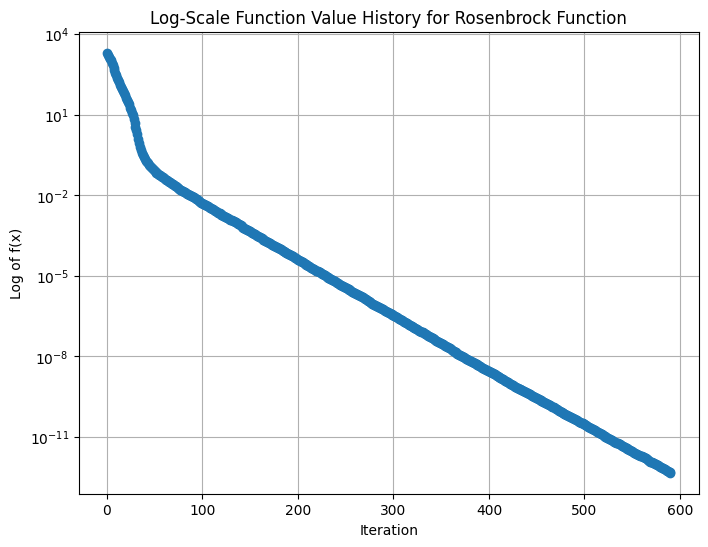

In [ ]:
# @title Rand Descent Exp (u ~ uniform [-1, 1] and Normalized, g normalized)

iter_list = []
time_list = []
for i in range(0, num_trials):
    # Run gradient descent
    solution_rosenbrock_rand, f_hist_rosenbrock_rand, x_hist_rosenbrock_rand, iterations_rosenbrock_rand, time_rosenbrock_rand = random_descent(
        rosenbrock_100d, grad_rosenbrock_function, x0, rand_scale= 1, randtype = "uniform", randnormed = True, gradnormed = True)

    iter_list.append(iterations_rosenbrock_rand)
    time_list.append(time_rosenbrock_rand)
print("average iteration count (in ", num_trials, " trials) = ", sum(iter_list) / len(iter_list))
print("average time (in ", num_trials, " trials) = ", sum(time_list) / len(time_list))

# Plotting the function value history on a log-scale
plt.figure(figsize=(8, 6))
plt.plot(f_hist_rosenbrock_rand, marker='o', linestyle='-')
plt.yscale('log')
plt.title('Log-Scale Function Value History for Rosenbrock Function')
plt.xlabel('Iteration')
plt.ylabel('Log of f(x)')
plt.grid(True)
plt.show()

In [ ]:
# @title Rand Descent Exp (u ~ normal and Normalized, g normalized)

iter_list = []
time_list = []
for i in range(0, num_trials):
    # Run gradient descent
    solution_rosenbrock_rand, f_hist_rosenbrock_rand, x_hist_rosenbrock_rand, iterations_rosenbrock_rand, time_rosenbrock_rand = random_descent(
        rosenbrock_100d, grad_rosenbrock_function, x0, rand_scale= 1, randtype = "normal", randnormed = True, gradnormed = True)

    iter_list.append(iterations_rosenbrock_rand)
    time_list.append(time_rosenbrock_rand)
print("average iteration count (in ", num_trials, " trials) = ", sum(iter_list) / len(iter_list))
print("average time (in ", num_trials, " trials) = ", sum(time_list) / len(time_list))

Converged!!
average iteration count (in  1  trials) =  590.0
average time (in  1  trials) =  35.79813742637634


In [ ]:
# @title Rand Descent Exp (u ~ normal and Normalized, g NOT normalized)

iter_list = []
time_list = []
for i in range(0, num_trials):
    # Run gradient descent
    solution_rosenbrock_rand, f_hist_rosenbrock_rand, x_hist_rosenbrock_rand, iterations_rosenbrock_rand, time_rosenbrock_rand = random_descent(
        rosenbrock_100d, grad_rosenbrock_function, x0, rand_scale= 1, randtype = "normal", randnormed = True, gradnormed = False)

    iter_list.append(iterations_rosenbrock_rand)
    time_list.append(time_rosenbrock_rand)
print("average iteration count (in ", num_trials, " trials) = ", sum(iter_list) / len(iter_list))
print("average time (in ", num_trials, " trials) = ", sum(time_list) / len(time_list))

Converged!!
average iteration count (in  1  trials) =  310.0
average time (in  1  trials) =  15.514030933380127


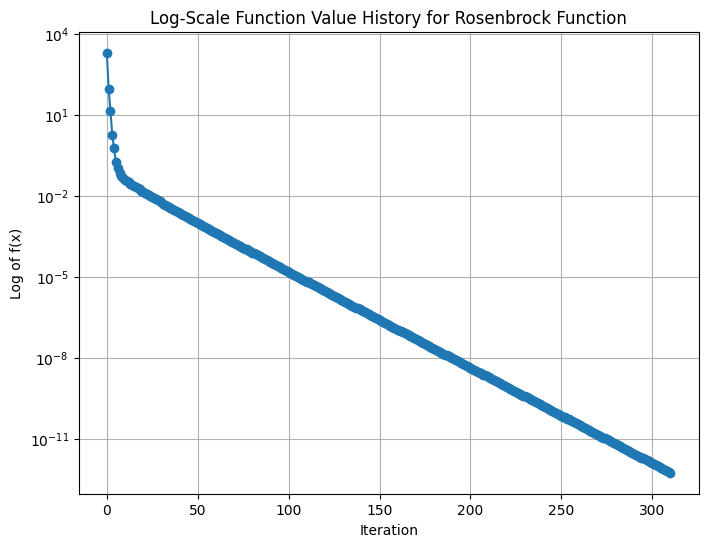

In [ ]:
# @title grad descent

iter_list = []
time_list = []
for i in range(0, num_trials):
    # Run gradient descent
    solution_rosenbrock_rand, f_hist_rosenbrock_rand, x_hist_rosenbrock_rand, iterations_rosenbrock_rand, time_rosenbrock_rand = gradient_descent(
        rosenbrock_100d, grad_rosenbrock_function, x0)

    iter_list.append(iterations_rosenbrock_rand)
    time_list.append(time_rosenbrock_rand)
print("average iteration count (in ", num_trials, " trials) = ", sum(iter_list) / len(iter_list))
print("average time (in ", num_trials, " trials) = ", sum(time_list) / len(time_list))

# Plotting the function value history on a log-scale
plt.figure(figsize=(8, 6))
plt.plot(f_hist_rosenbrock_rand, marker='o', linestyle='-')
plt.yscale('log')
plt.title('Log-Scale Function Value History for Rosenbrock Function')
plt.xlabel('Iteration')
plt.ylabel('Log of f(x)')
plt.grid(True)
plt.show()
